# Project 3 Code
Kristal Lee\
DSC 680\
Spring 2025\

In [1]:
# import initial libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# load data
location= 'data.csv'

df = pd.read_csv(location, sep=';',header=0)

In [11]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [14]:
df['Target'].unique()

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

In [15]:
# define target and features
target = df['Target']
features = df.drop(['Target'], axis=1)

In [17]:
target.unique()

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

In [19]:
rm = {'Dropout': 0, 'Graduate': 1, 'Enrolled':2}
target = target.replace(rm)

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [23]:
# find VIF for each feature to check for multilinearity
vif_data = pd.DataFrame()
vif_data['feature'] = features.columns
vif_data['VIF'] = [variance_inflation_factor(features.values, i) for i in range(len(features.columns))]

In [38]:
vif_sorted = vif_data.sort_values(by='VIF', ascending=False)

In [40]:
above_10 = vif_sorted[vif_sorted['VIF'] >10]

In [62]:
rm_abv_10 = above_10['feature'].to_list()

In [63]:
features2 = features.drop(rm_abv_10, axis=1)

In [68]:
# print(features.shape)
# print(features2.shape)

## Appendix - B

In [67]:
from sklearn.model_selection import train_test_split

In [69]:
# split 80/20 testing and training sets
features_train, features_test, target_train, target_test = train_test_split(features2, target, test_size=0.2, random_state=0)

In [70]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import preprocessing
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import GridSearchCV

In [71]:
# set the min ma x scaler 
minmax_scale = preprocessing.MinMaxScaler(feature_range=(0,1))
# knn classifier with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
# pipeline
pipe = Pipeline([('min-max', minmax_scale), ('knn', knn)])

In [72]:
# create seach space for number of nearest neighbors
search_space = [{"knn__n_neighbors": [2, 3, 4, 5, 6, 7]}]

In [73]:
# create a model with the best value for n neighbors
classifier = GridSearchCV(pipe, search_space, cv=5, verbose=0).fit(features_train, target_train)

In [74]:
print("Best value for n_neighbors:",classifier.best_estimator_.get_params()["knn__n_neighbors"])

Best value for n_neighbors: 7


In [75]:
# predicted values for new model
pred_best = classifier.predict(features_test)

In [76]:
from sklearn.metrics import accuracy_score

In [93]:
# calculate accuracy for KNN model
knn_acc = accuracy_score(target_test, pred_best)
print("KNN [k=7] Accuracy: {0:.3f} ".format(knn_acc))

KNN [k=7] Accuracy: 0.559 


In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [79]:
# create pipeline with min-max scaler
pipe2 = Pipeline([('min-max', minmax_scale), ('classifier', RandomForestClassifier())])

In [94]:
search_space2 = [{'classifier': [LogisticRegression(max_iter=500,
                                                    solver='liblinear')],
                                 'classifier__penalty':['l1', 'l2'],
                                 'classifier__C': np.logspace(0, 4, 10)},
                 {'classifier': [RandomForestClassifier()], 
                  'classifier__n_estimators': [10, 100, 1000],
                  'classifier__max_features': [1, 2, 3]},
                {'classifier':[KNeighborsClassifier(n_neighbors=7, n_jobs=-1)]}]

In [95]:
# create the new classifier
classifier2 = GridSearchCV(pipe2, search_space2, cv=5, verbose=0)

In [96]:
# fit model
best_model = classifier2.fit(features_train, target_train)

In [97]:
# results for best model
print(best_model.best_estimator_)

Pipeline(steps=[('min-max', MinMaxScaler()),
                ('classifier',
                 LogisticRegression(C=464.15888336127773, max_iter=500,
                                    solver='liblinear'))])


In [98]:
# predictions from model
pred_best2 = best_model.predict(features_test)

In [99]:
# accuracy of best selected model
acc2 = accuracy_score(target_test, pred_best2)
print("Log Reg. Accuracy: {0:.3f} ".format(acc2))

Log Reg. Accuracy: 0.597 


In [100]:
log_model = LogisticRegression(C=464.15888336127773, max_iter=500, penalty='l1', solver='liblinear')

In [101]:
log_model.fit(features_train, target_train)

LogisticRegression(C=464.15888336127773, max_iter=500, penalty='l1',
                   solver='liblinear')

In [102]:
best_pred = log_model.predict(features_test)

In [103]:
acc_best = accuracy_score(target_test, best_pred)
print("Log Reg. Accuracy: {0:.3f} ".format(acc_best))

Log Reg. Accuracy: 0.597 


In [104]:
# get coefficients for log model
coefficients = log_model.coef_[0]

<Axes: ylabel='Feature'>

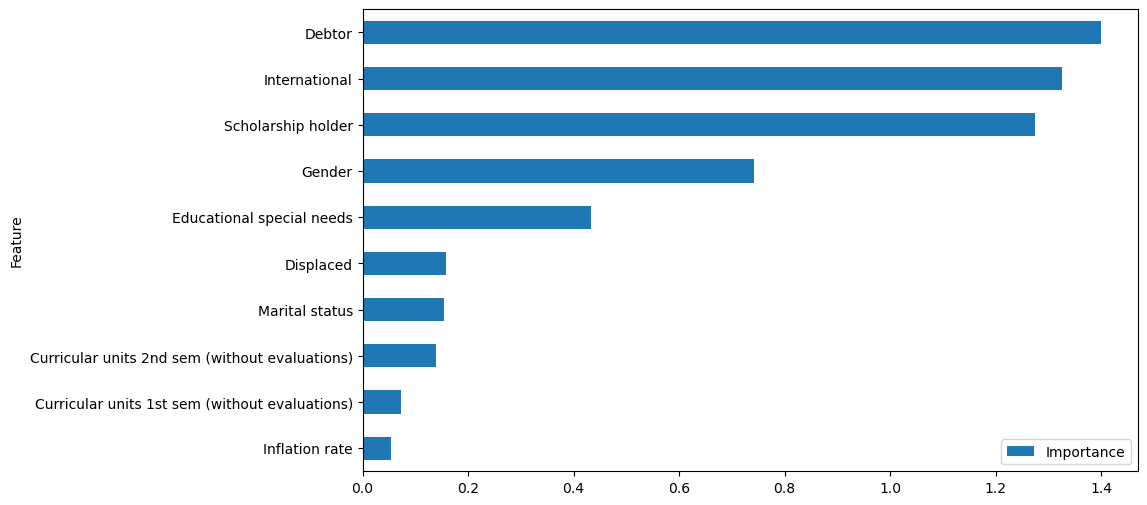

In [105]:
# plot top ten coefficients for Log Model
feature_importance = pd.DataFrame({'Feature': features_train.columns, 'Importance': np.abs(coefficients)})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
top10_features = feature_importance.sort_values('Importance', ascending=False)[:10]
top10_features.sort_values('Importance', ascending=True).plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6))

In [125]:
debtor = df[['Target', 'Debtor']]
debtor.columns = ['Enrollment Status','Debtor']
debtor.groupby('Enrollment Status').sum()

,Debtor
Enrollment Status,
Dropout,312
Enrolled,90
Graduate,101


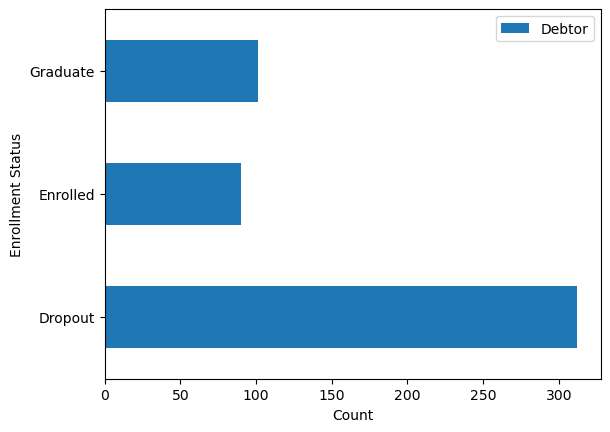

In [121]:
debtor.groupby('Enrollment Status').sum().plot.barh()
plt.xlabel('Count')
plt.ylabel('Enrollment Status')
plt.show()

                   international
Enrollment Status               
Dropout                       32
Enrolled                      24
Graduate                      54


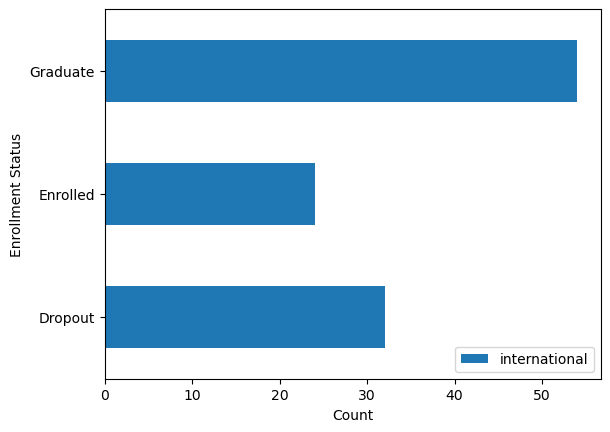

In [126]:
international = df[['Target', 'International']]
international.columns = ['Enrollment Status','international']
print(international.groupby('Enrollment Status').sum())
international.groupby('Enrollment Status').sum().plot.barh()
plt.xlabel('Count')
plt.ylabel('Enrollment Status')
plt.show()

                   Scholarship Holder
Enrollment Status                    
Dropout                           134
Enrolled                          130
Graduate                          835


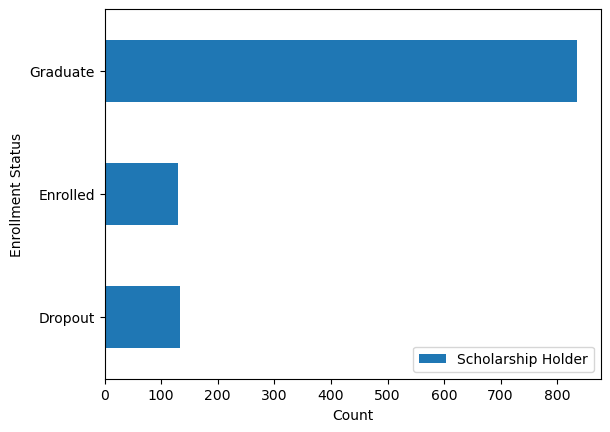

In [127]:
scholarship = df[['Target', 'Scholarship holder']]
scholarship.columns = ['Enrollment Status','Scholarship Holder']
print(scholarship.groupby('Enrollment Status').sum())
scholarship.groupby('Enrollment Status').sum().plot.barh()
plt.xlabel('Count')
plt.ylabel('Enrollment Status')
plt.show()